### Лабораториска вежба 1


---


Класификација со Naïve Bayes и Gaussian Discriminant Analysis модели (LDA и QDA)

In [100]:
import matplotlib.pyplot as plt #Libraries for visualization
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import numpy as np #Library for numerical calculations
from scipy import stats #Library for statistical analysis
from sklearn import datasets #Libraries for machine learning
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

### 1. Читање на податочното множество

In [101]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data'
data = pd.read_csv(url, header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [102]:
names=['ID','RI','Na','Mg','Al','Si','K','Ca','Ba','Fe','glass_type']
data.columns=names
data.head()

,ID,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,glass_type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [103]:
data.describe()

,ID,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,glass_type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,107.500000,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,61.920648,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.000000,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,54.250000,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,107.500000,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,160.750000,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,214.000000,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [104]:
X=data.drop('glass_type', axis=1).values
y=data['glass_type'].values

target_names=data['glass_type'].unique()
feature_names=data.drop('glass_type', axis=1).columns

number_of_features=X.shape[1]
number_of_classes=len(np.unique(y))

print(number_of_features)
print(number_of_classes)

10
6


In [105]:
print(f'Number and names of classes: {number_of_classes} {target_names}')
print(f'Number and names of features: {number_of_features} {feature_names}')

Number and names of classes: 6 [1 2 3 5 6 7]
Number and names of features: 10 Index(['ID', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'], dtype='object')


Бидејќи glass_type има повеќе вредности, станува збор за multiclass calssification

### 2. Следно ќе провериме дали има missing values и дали множеството е балансирано.

In [106]:
data.isnull().sum()

,0
ID,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0


In [107]:
data.value_counts('glass_type')

,count
glass_type,
2,76
1,70
7,29
3,17
5,13
6,9


<Axes: xlabel='glass_type'>

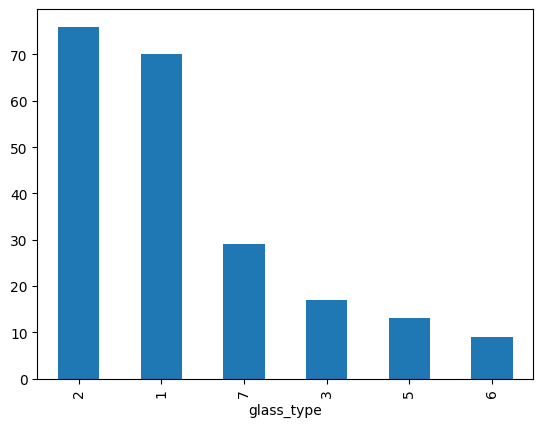

In [108]:
data["glass_type"].value_counts().plot.bar()

### 3. Анализа на податоците и визуелизации




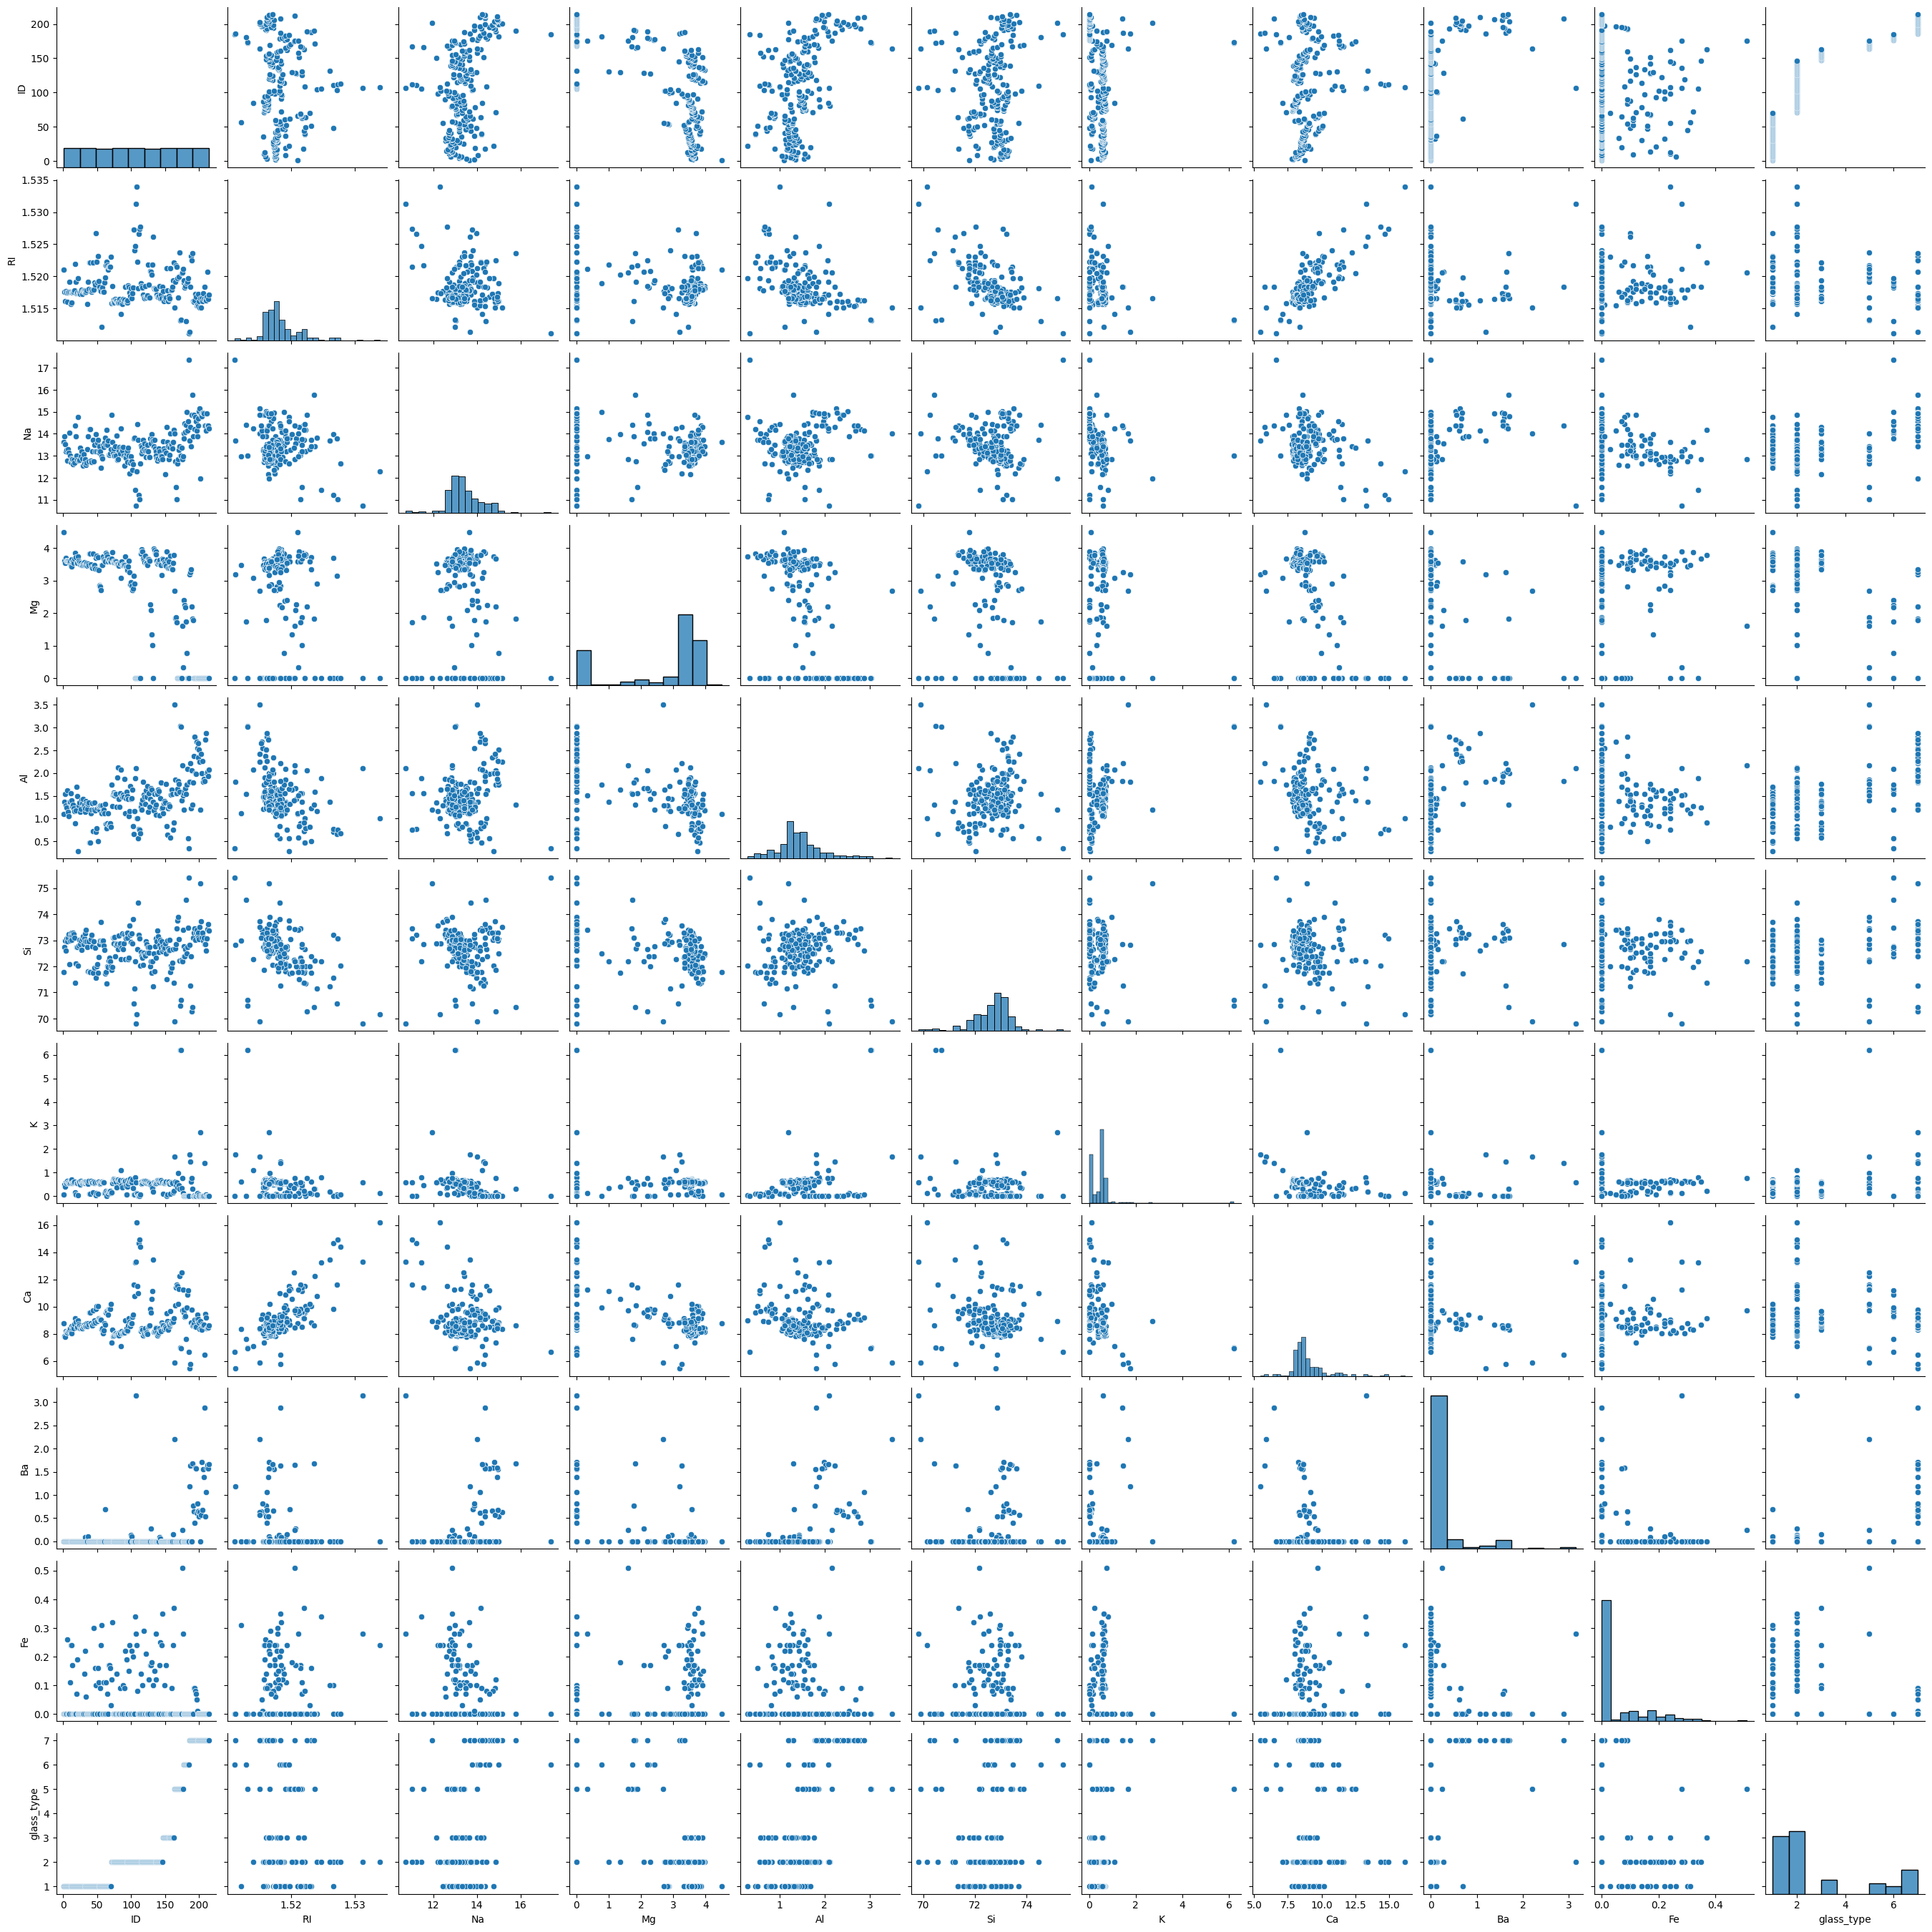

In [109]:
sns.pairplot(data)

## Heatmap

---



<Axes: >

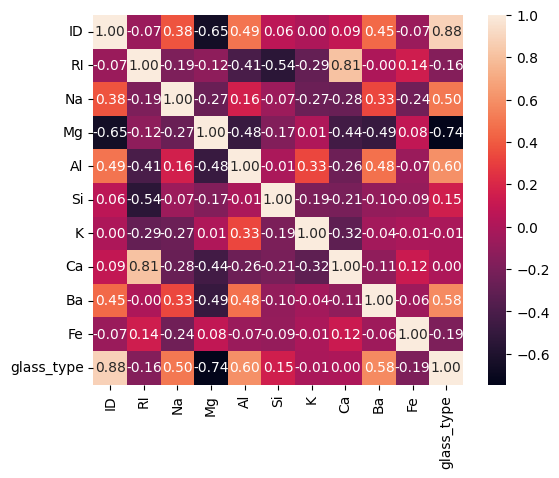

In [110]:
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", square=True)


Од оваа Heatmap може да се види дека Ca има висока корелација со RI, односно тоа значи дека кога Ca расте, и RI расте и обратно. Од ова може да се заклучи дека постои линеарна врска меѓу нив.
Проблемот тука е што кога две карактеристики се високо корелирани, тие носат иста информација што може да доведе до полоши перформанси кај некои модели.

# Хистограми

---
Со помош на хистограмите може да ја видиме дистрибуцијата на секој feature, односно дали се нормално распределени или рамномерно итд. Исто така може да видиме дали има Outliers.
Може да видиме дали feature-от може да разделува класи.


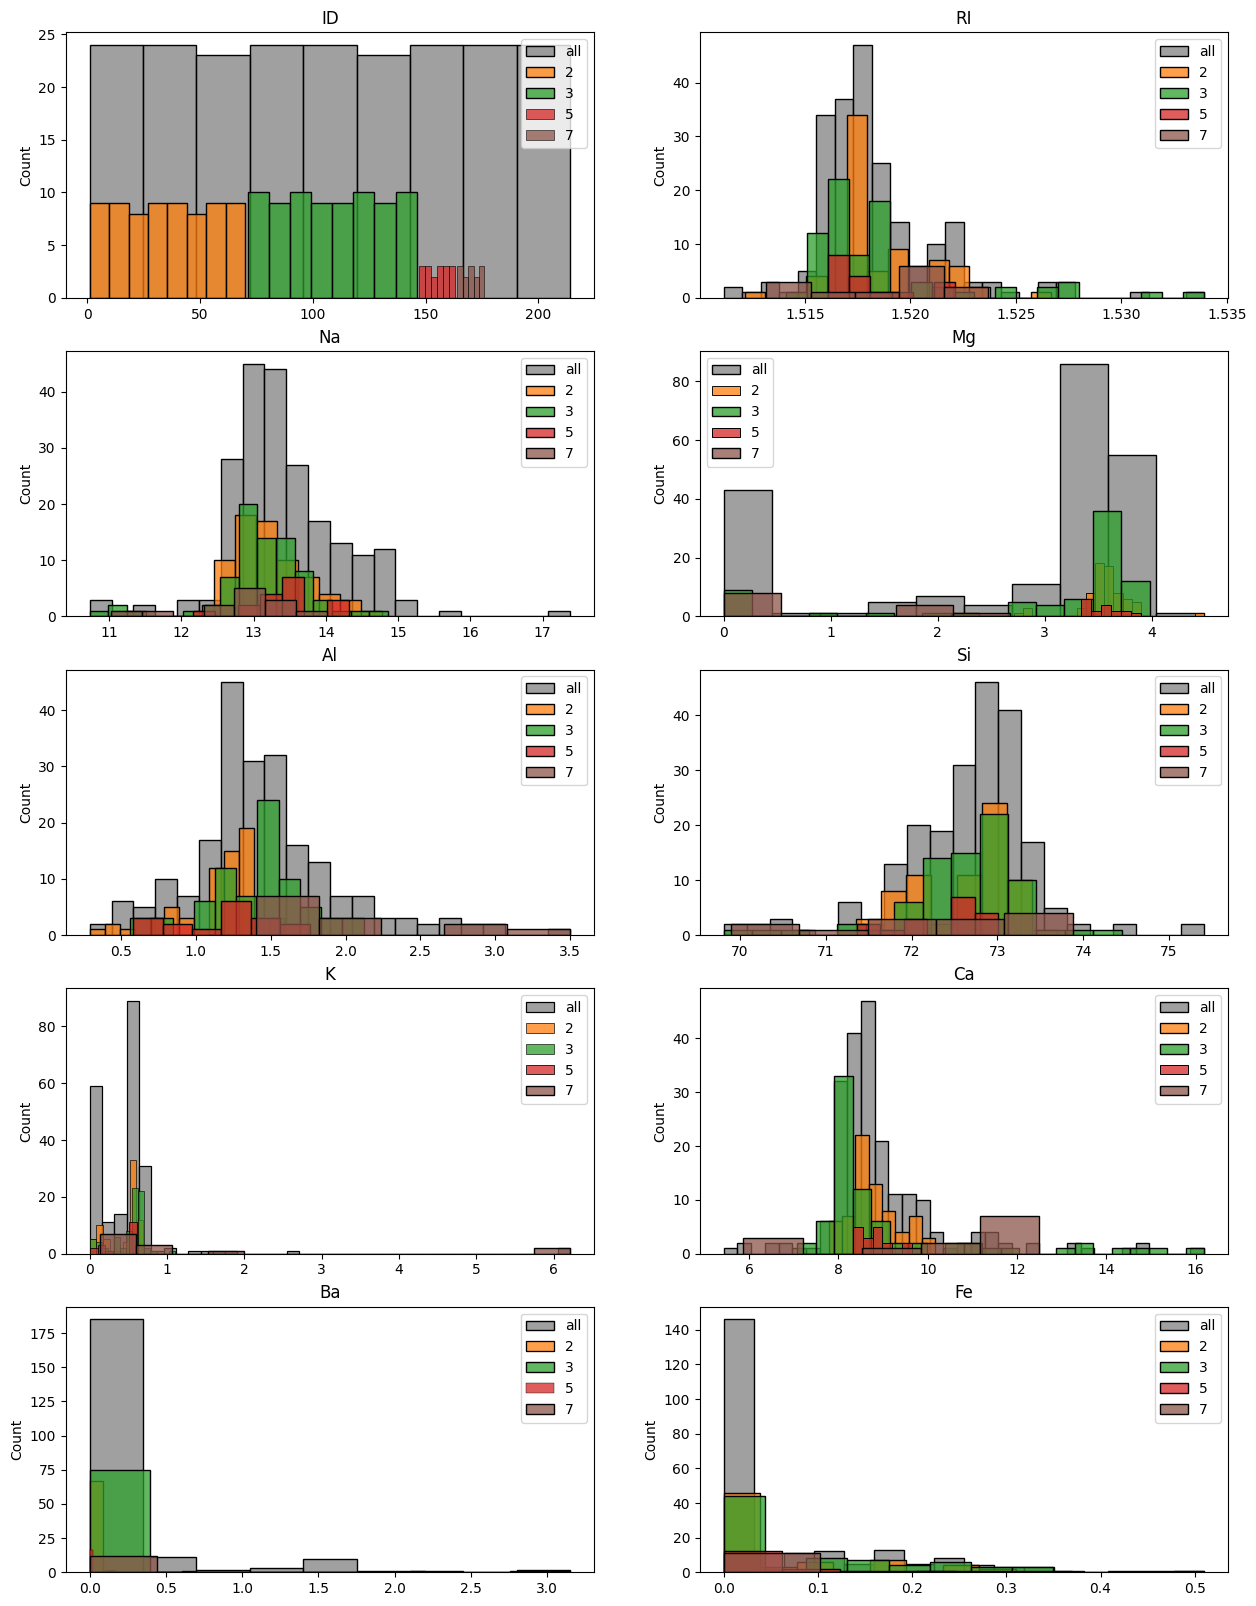

In [111]:
fig = plt.figure(figsize=(15, 20))
fig.subplots(nrows=5, ncols=2)
for feat_i in range(number_of_features): #For each feature, we have a new subplot
    ax = plt.subplot(5,2, feat_i+1)
    plt.title(feature_names[feat_i])
    sns.histplot(X[:,feat_i],color='grey',label='all') #Once we have a specific feature, we draw the histogram of the feature's data (X[:,i] means we get the i'th column of X)
    for class_i in range(number_of_classes): #After that we draw the within-class histograms of the same feature
        sns.histplot(X[y == class_i,feat_i], label=target_names[class_i]) # (X[y==c,i] means we get the i'th column of X where the class in the same row in y is equal to c
    plt.legend()
plt.show()

In [112]:
data['ID'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

Бидејќи ID  е уникатно и дополнително од хистограмот може да се види дека има рамномерна дистрибуција, не ни е корисен feature и истиот треба да се drop.

In [113]:
data.drop(columns=["ID"], inplace=True)

In [114]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,glass_type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Скатерплотови


---



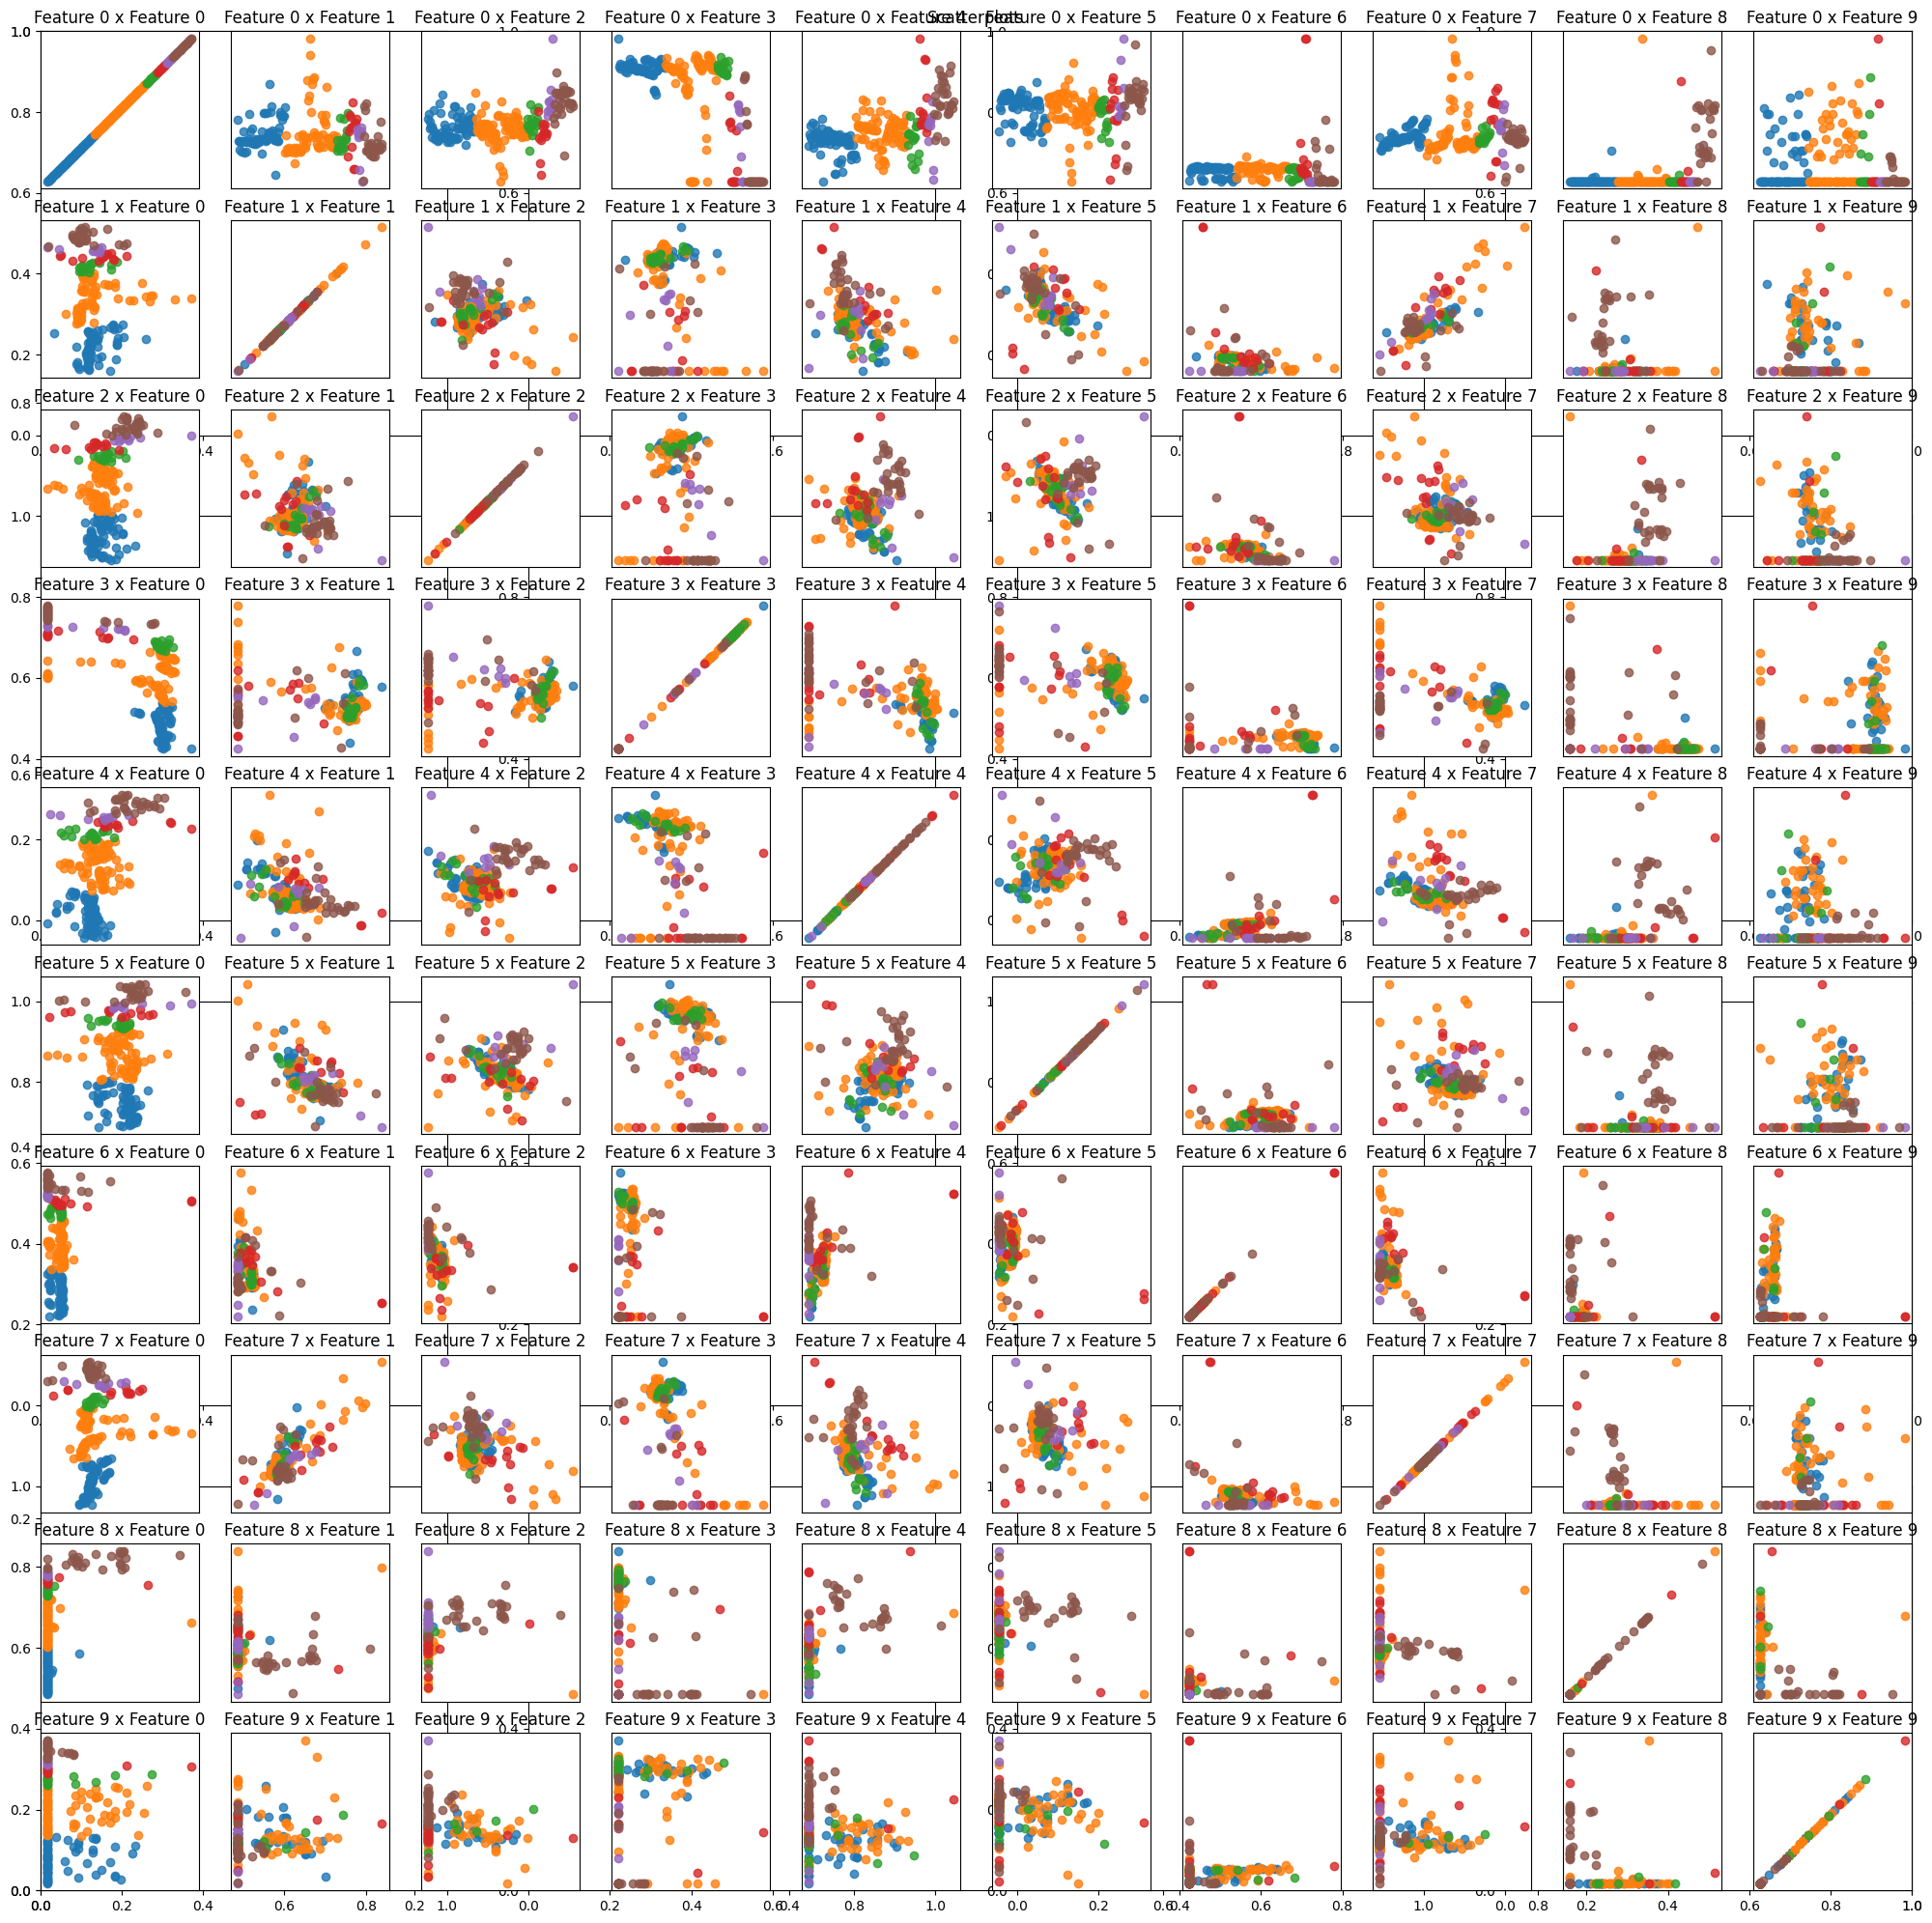

In [115]:
fig = plt.figure(figsize=(25, 25))
plt.title("Scatterplots")
fig.subplots(nrows=4, ncols=4)

for feat_i in range(number_of_features): #We go over all pairs of features (4x4 in this case)
    for feat_j in range(number_of_features):
        ax = plt.subplot(10,10,number_of_features*feat_i + feat_j+1)
        # Plot the points
        for target_name in zip(target_names):
            plt.scatter(X[y == target_name, feat_i], X[y == target_name, feat_j], alpha=.8, label=target_name) #We again extract the feature class specific data using the same method as before and then just use the scatter function
        plt.xticks(())
        plt.yticks(())
        plt.title("Feature "+str(feat_i)+" x Feature "+str(feat_j))
plt.show()

 Од овие скатерплотови може да заклучиме дека класите не се линеарно одделиви, односно нема права линија која ги разделува.

### Box plots


---
Визуелизација на распределбата на податоците за сите променливи.


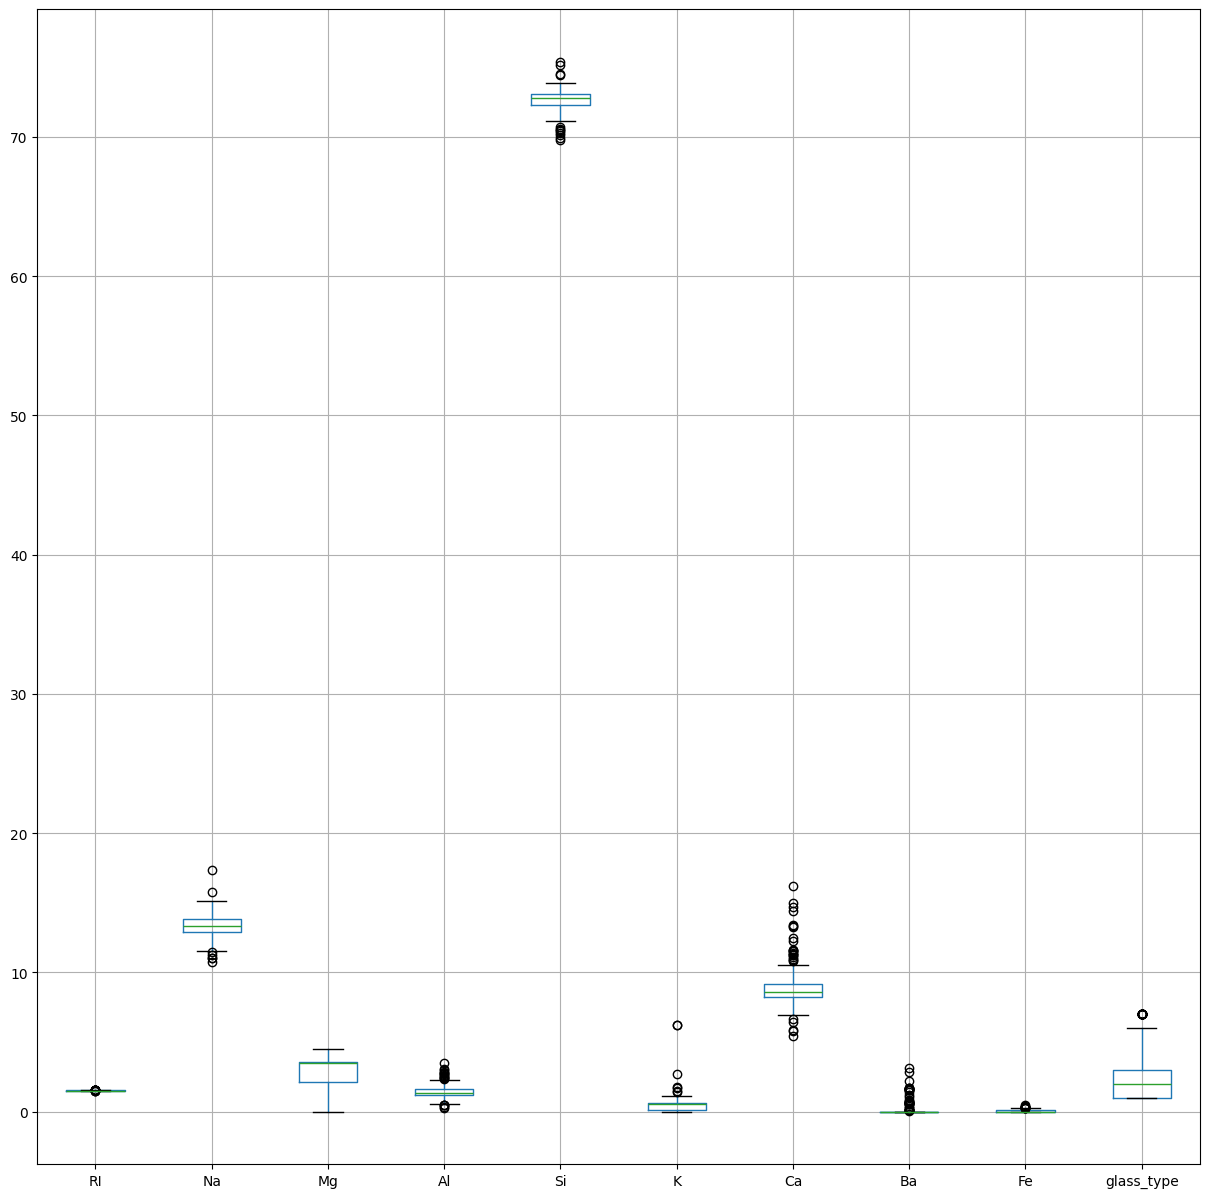

In [116]:
fig = plt.figure(figsize=(15, 15))
data.boxplot()
plt.show()

### 4. Поделба на податочното множество на тренинг и тест.

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Класификација со квадратна дискриминативна анализа**

In [118]:
QDA = QuadraticDiscriminantAnalysis()
QDA.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

QuadraticDiscriminantAnalysis()

In [119]:
print("Приорните веројатности на класите се",QDA.priors_)

Приорните веројатности на класите се [0.34228188 0.3557047  0.08724832 0.04697987 0.04026846 0.12751678]


In [120]:
y_pred = QDA.predict(X_test)
QDA_accuracy = accuracy_score(y_test, y_pred)

print("Точноста на класификацијата со методот QDA е",round(QDA_accuracy,3))

Точноста на класификацијата со методот QDA е 0.062


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1052: RuntimeWarning: divide by zero encountered in power
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1052: RuntimeWarning: invalid value encountered in multiply
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1055: RuntimeWarning: divide by zero encountered in log
  u = np.asarray([np.sum(np.log(s)) for s in self.scalings_])


In [121]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        19
           2       0.00      0.00      0.00        23
           3       0.06      1.00      0.12         4
           5       0.00      0.00      0.00         6
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00        10

    accuracy                           0.06        65
   macro avg       0.01      0.17      0.02        65
weighted avg       0.00      0.06      0.01        65



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Тука се гледа дека recall=1 за класа 3, а 0 за сите останати, ова значи дека моделот предвидува само една калса. Со додавање на reg_param што е мала вредност која се додава на дијагоналата на коваријантните матрици, се добиваат многу подобри резултати.

In [133]:
QDA = QuadraticDiscriminantAnalysis(reg_param=0.1)
QDA = QuadraticDiscriminantAnalysis(reg_param=0.5, store_covariance=True) #se dodava mala vrednost na dijagonalata na cov matrix
QDA.fit(X_train, y_train)
y_pred = QDA.predict(X_test)
QDA_accuracy = accuracy_score(y_test, y_pred)

print("Точноста на класификацијата со методот QDA е",round(QDA_accuracy,3))

Точноста на класификацијата со методот QDA е 0.985


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 4 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [134]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      0.96      0.98        23
           3       0.80      1.00      0.89         4
           5       1.00      1.00      1.00         6
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00        10

    accuracy                           0.98        65
   macro avg       0.97      0.99      0.98        65
weighted avg       0.99      0.98      0.99        65



### **Класификација со линеарна дискриминативна анализа**

In [122]:
LDA = LinearDiscriminantAnalysis()
LDA.fit(X_train, y_train)
y_pred = LDA.predict(X_test)
LDA_accuracy = accuracy_score(y_test, y_pred)

print("Точноста на класификацијата со методот LDA е",round(LDA_accuracy,3))

Точноста на класификацијата со методот LDA е 0.862


In [123]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      0.95      0.97        19
           2       0.96      0.96      0.96        23
           3       0.57      1.00      0.73         4
           5       1.00      0.33      0.50         6
           6       0.33      0.67      0.44         3
           7       0.89      0.80      0.84        10

    accuracy                           0.86        65
   macro avg       0.79      0.78      0.74        65
weighted avg       0.91      0.86      0.86        65



### **Класификација со Наивен Баесов класификатор**

In [124]:
GNB = GaussianNB()
GNB.fit(X_train, y_train)
y_pred = GNB.predict(X_test)
GNB_accuracy = accuracy_score(y_test, y_pred)

print("Точноста на класификацијата со Гаусовиот наивен Баесов класификатор е",round(GNB_accuracy,3))

Точноста на класификацијата со Гаусовиот наивен Баесов класификатор е 0.785


In [125]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.75      0.95      0.84        19
           2       0.81      0.57      0.67        23
           3       0.43      0.75      0.55         4
           5       1.00      0.83      0.91         6
           6       1.00      0.67      0.80         3
           7       0.91      1.00      0.95        10

    accuracy                           0.78        65
   macro avg       0.82      0.79      0.79        65
weighted avg       0.81      0.78      0.78        65



Бидејќи сите карактеристики имаат различни рангови на вредности, добро е да се скалира податочното множество.

In [126]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [127]:
QDA = QuadraticDiscriminantAnalysis()
QDA.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 4 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


QuadraticDiscriminantAnalysis()

In [128]:
print("Приорните веројатности на класите се",QDA.priors_)

Приорните веројатности на класите се [0.34228188 0.3557047  0.08724832 0.04697987 0.04026846 0.12751678]


In [129]:
y_pred = QDA.predict(X_test_scaled)
QDA_accuracy = accuracy_score(y_test, y_pred)

print("Точноста на класификацијата со методот QDA на скалирани податоци е",round(QDA_accuracy,3))

Точноста на класификацијата со методот QDA на скалирани податоци е 0.815


In [130]:
LDA = LinearDiscriminantAnalysis()
LDA.fit(X_train_scaled, y_train)
y_pred = LDA.predict(X_test_scaled)
LDA_accuracy = accuracy_score(y_test, y_pred)

print("Точноста на класификацијата со методот LDA на скалирани податоци е",round(LDA_accuracy,3))

Точноста на класификацијата со методот LDA на скалирани податоци е 0.862


In [131]:
GNB = GaussianNB()
GNB.fit(X_train_scaled, y_train)
y_pred = GNB.predict(X_test_scaled)
GNB_accuracy = accuracy_score(y_test, y_pred)

print("Точноста на класификацијата со Гаусовиот наивен Баесов класификатор на скалирани податоци е",round(GNB_accuracy,3))

Точноста на класификацијата со Гаусовиот наивен Баесов класификатор на скалирани податоци е 0.815


Може да заклучиме дека доколку го скалираме податочното множество се добиваат подобри резултати.

### 4. Заклучок


---
Во оваа лабораториска вежба беа споредени три класификатори: Gaussian Naïve Bayes, Linear Discriminant Analysis (LDA) и Quadratic Discriminant Analysis (QDA) на Glass Identification податочното множество.

Од сите анализи на податочното множество, може да се забележи дека има корелација меѓу карактеристиките, од heatmap се гледа дека Ca и RI се корелирани, а од scatterplots се гледа дека класите не се линеарно одделиви. Поради тоа, претпоставката за целосна независност кај Naive Bayes не е целосно исполнета, бидејќи нели Naive Bayes претпоставува дека сите карактеристики се независни. Исто така поради претпоставката за линеарна граница на одлука кај LDA, моделот може да биде недоволно флексибилен за да ги опише покомплексните односи помеѓу класите.
Најпрвин, QDA без регуларизација даде многу лоши резултати (accuracy = 0.06). Анализата на classification report покажа дека моделот предвидува исклучиво класа 3 (recall = 1.00 за класа 3, а 0.00 за сите останати класи).
Со воведување на регуларизација, перформансите на QDA се подобрија (accuracy = 0.98).
Ова покажува дека QDA иако е пофлексибилен модел бидејќи ги зема во предвид коваријантните матрици бара соодветна регуларизација за да работи успешно на мали и небалансирани податоци.
Дополнително, скалирањето на податоците доведе до подобрување на перформансите на моделите.